In [ ]:
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sns
import datetime

In [6]:
data = "marketing_campaign.csv"

In [45]:
CURRENT_YEAR= 2026
CURRENT_DATE = pd.Timestamp.today().date()
print(f"{CURRENT_DATE}: {type(CURRENT_DATE)}")

2026-03-20: <class 'datetime.date'>


In [7]:
df= pd.read_csv(data,sep='\t')
df = df.dropna(axis=1)
df_copy = df.copy()

print(f" Number of data points : {len(df_copy)}")
df.head()

 Number of data points : 2240


,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


In [12]:
col_names= list(df_copy.columns)
df_copy =  df_copy.drop(col_names[0],axis=1)
print(col_names)

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [ ]:
target = df_copy['MntWines'].copy()
df_copy.head()

,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,0,0,04-09-2012,58,635,88,546,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,1,1,08-03-2014,38,11,1,6,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,0,0,21-08-2013,26,426,49,127,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,1,0,10-02-2014,26,11,4,20,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,1,0,19-01-2014,94,173,43,118,...,5,0,0,0,0,0,0,3,11,0


In [19]:
cols_to_ohe =[]
for c in col_names[1:]:
    num_unique = df_copy[c].nunique()
    if num_unique>=2 and num_unique<10: 
        print(f"{c} : {num_unique}")
        print(f"{df_copy[c].unique()}")
        if num_unique>2: 
           cols_to_ohe.append(c) 
print(f"Cols to OHE: {cols_to_ohe}")

Education : 5
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital_Status : 8
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
Kidhome : 3
[0 1 2]
Teenhome : 3
[0 1 2]
AcceptedCmp3 : 2
[0 1]
AcceptedCmp4 : 2
[0 1]
AcceptedCmp5 : 2
[0 1]
AcceptedCmp1 : 2
[0 1]
AcceptedCmp2 : 2
[0 1]
Complain : 2
[0 1]
Response : 2
[1 0]
Cols to OHE: ['Education', 'Marital_Status', 'Kidhome', 'Teenhome']


In [64]:
df_encoded = pd.get_dummies(df_copy, columns=cols_to_ohe, drop_first=False)
df_encoded.head()

,Year_Birth,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Kidhome_0,Kidhome_1,Kidhome_2,Teenhome_0,Teenhome_1,Teenhome_2
0,1957,04-09-2012,58,635,88,546,172,88,88,3,...,True,False,False,False,True,False,False,True,False,False
1,1954,08-03-2014,38,11,1,6,2,1,6,2,...,True,False,False,False,False,True,False,False,True,False
2,1965,21-08-2013,26,426,49,127,111,21,42,1,...,False,True,False,False,True,False,False,True,False,False
3,1984,10-02-2014,26,11,4,20,10,3,5,2,...,False,True,False,False,False,True,False,True,False,False
4,1981,19-01-2014,94,173,43,118,46,27,15,5,...,False,False,False,False,False,True,False,True,False,False


In [65]:
df_encoded['CustomerPeriod'] = CURRENT_YEAR- df_encoded["Dt_Customer"].str[-4:].astype(int)

df_encoded = df_encoded.drop(columns=["Dt_Customer"])


df_encoded['AGE'] = CURRENT_YEAR - df_encoded["Year_Birth"]

df_encoded = df_encoded.drop(columns=["Year_Birth"])

df_encoded.head()

,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,...,Marital_Status_Widow,Marital_Status_YOLO,Kidhome_0,Kidhome_1,Kidhome_2,Teenhome_0,Teenhome_1,Teenhome_2,CustomerPeriod,AGE
0,58,635,88,546,172,88,88,3,8,10,...,False,False,True,False,False,True,False,False,14,69
1,38,11,1,6,2,1,6,2,1,1,...,False,False,False,True,False,False,True,False,12,72
2,26,426,49,127,111,21,42,1,8,2,...,False,False,True,False,False,True,False,False,13,61
3,26,11,4,20,10,3,5,2,2,0,...,False,False,False,True,False,True,False,False,12,42
4,94,173,43,118,46,27,15,5,5,3,...,False,False,False,True,False,True,False,False,12,45


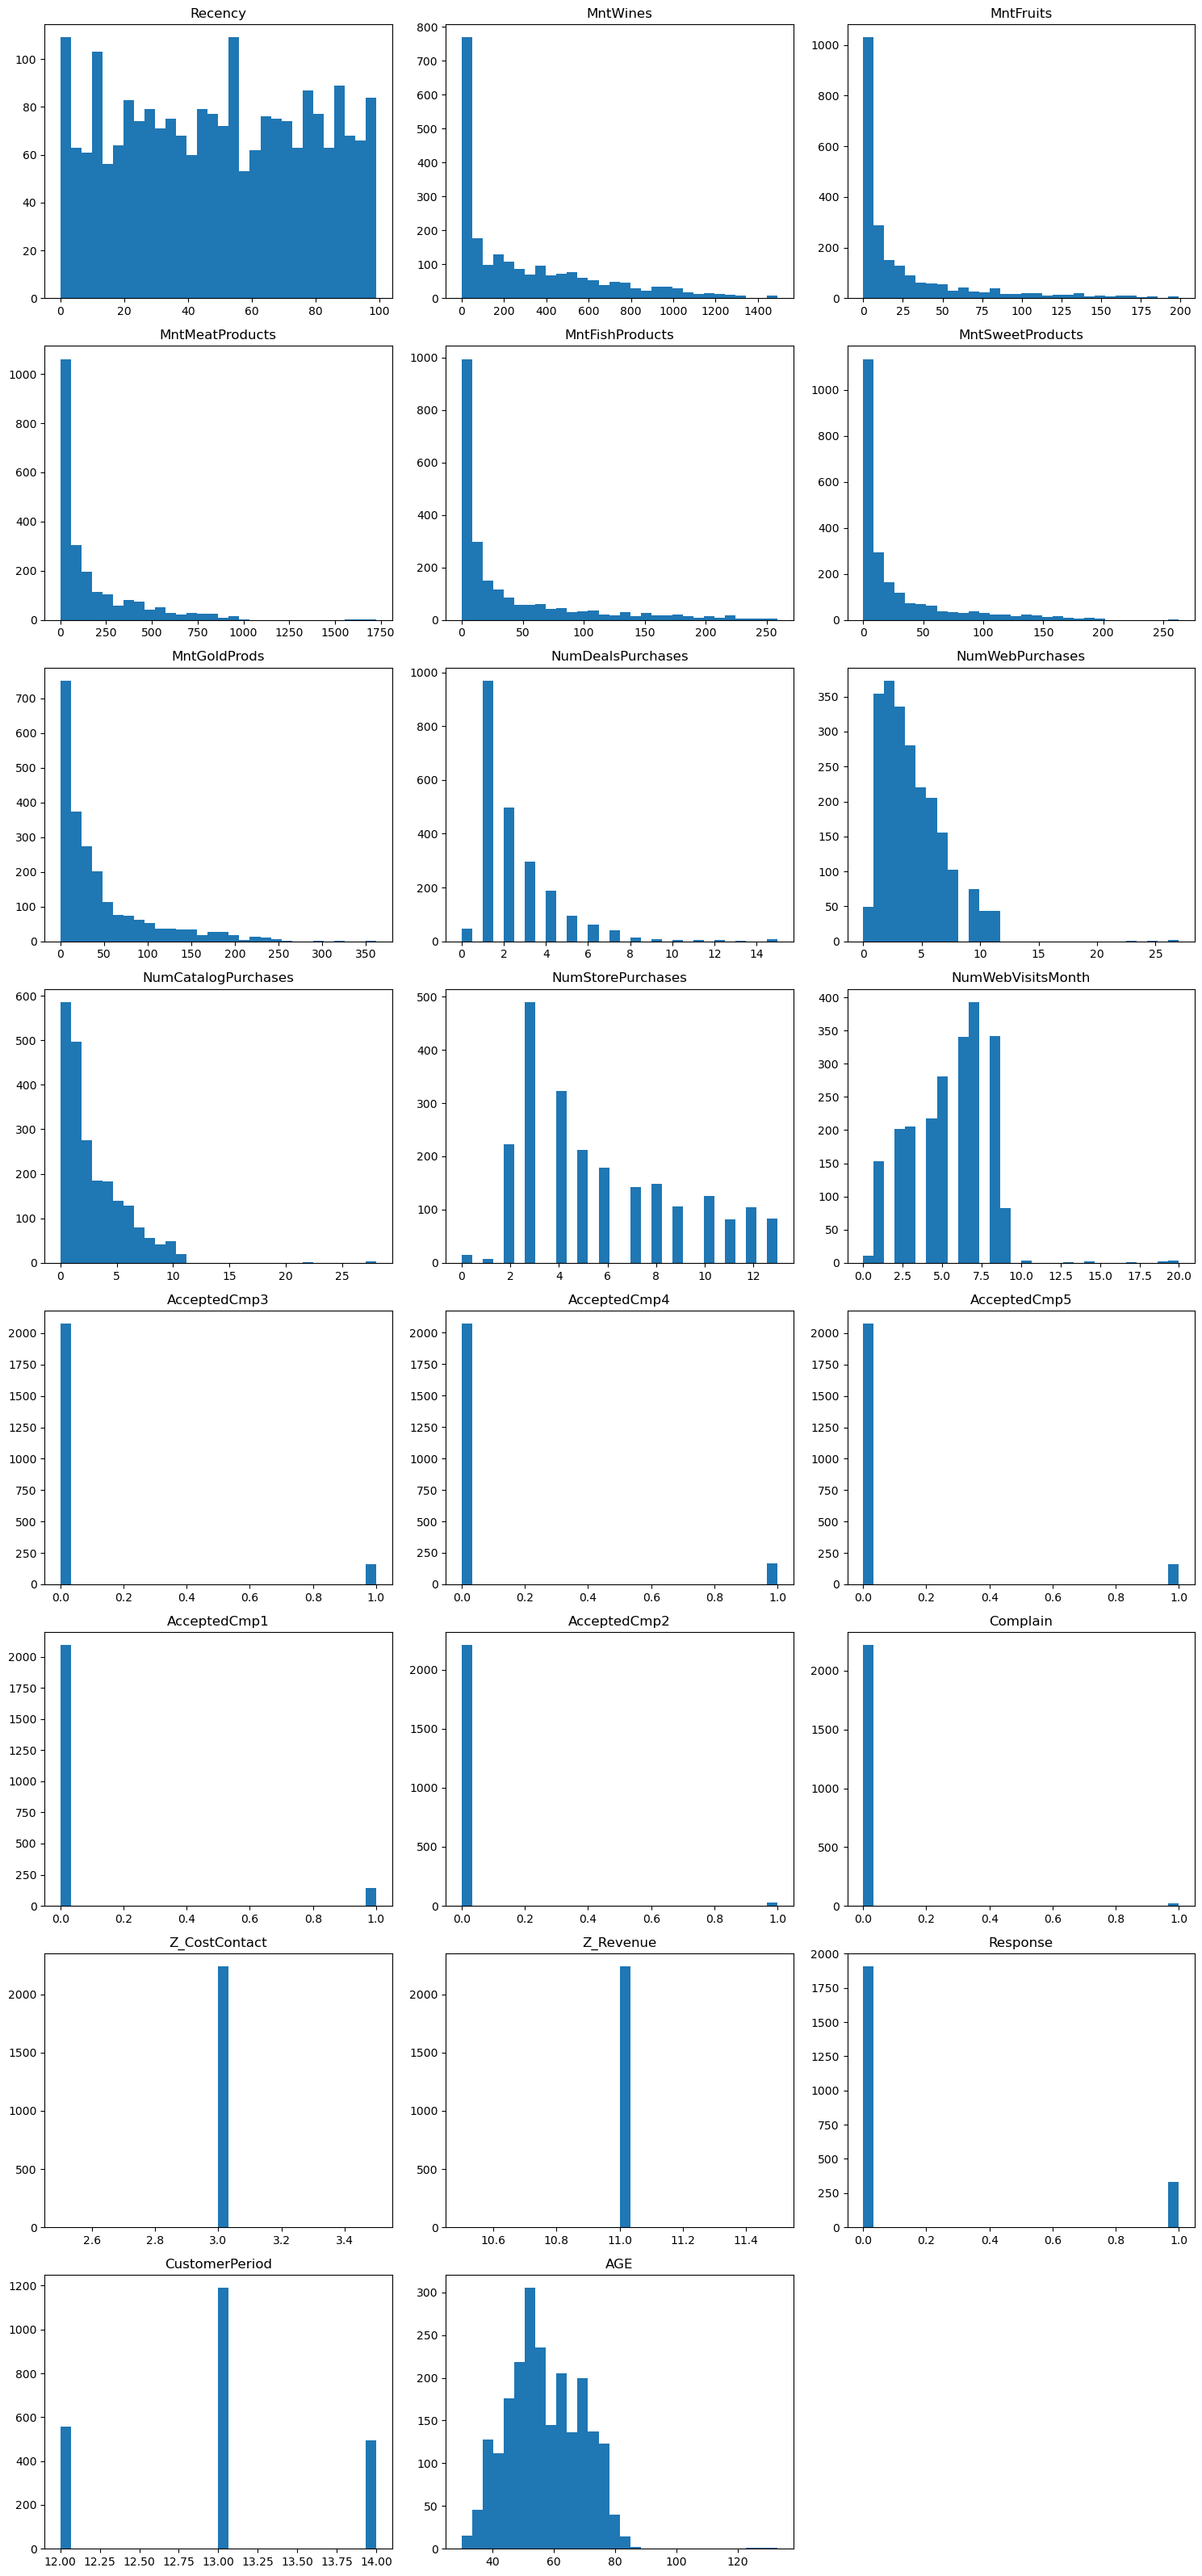

In [66]:
import matplotlib.pyplot as plt
import math

num_cols = df_encoded.select_dtypes(include='number').columns
n = len(num_cols)

cols = 3  # number of plots per row
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df_encoded[col].dropna(), bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [67]:
df_encoded_cols = df_encoded.columns
print(df_encoded_cols)

Index(['Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Absurd',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO', 'Kidhome_0', 'Kidhome_1', 'Kidhome_2',
       'Teenhome_0', 'Teenhome_1', 'Teenhome_2', 'CustomerPeriod', 'AGE'],
      dtype='object')


In [70]:
from sklearn.model_selection import train_test_split
y = df_encoded[df_encoded_cols[1]].copy()  
X = df_encoded.drop(df_encoded_cols[1], axis=1)  # features
              # target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test
    random_state=42     # reproducibility
)
X.head()

,Recency,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Marital_Status_Widow,Marital_Status_YOLO,Kidhome_0,Kidhome_1,Kidhome_2,Teenhome_0,Teenhome_1,Teenhome_2,CustomerPeriod,AGE
0,58,88,546,172,88,88,3,8,10,4,...,False,False,True,False,False,True,False,False,14,69
1,38,1,6,2,1,6,2,1,1,2,...,False,False,False,True,False,False,True,False,12,72
2,26,49,127,111,21,42,1,8,2,10,...,False,False,True,False,False,True,False,False,13,61
3,26,4,20,10,3,5,2,2,0,4,...,False,False,False,True,False,True,False,False,12,42
4,94,43,118,46,27,15,5,5,3,6,...,False,False,False,True,False,True,False,False,12,45


In [71]:
cols_with_num = df_encoded.select_dtypes(include='number').columns.tolist()
print(cols_with_num)


['Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'CustomerPeriod', 'AGE']


Normalization for Gaussian

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
num_cols = df_encoded.select_dtypes(include='number').columns
STDscaler = StandardScaler()#Gauss
mimMaxscaler = MinMaxScaler()#Uniform
robusrScaler = RobustScaler()#Skewed
choose_scaler = [1,2,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,0]
scalers = [STDscaler,mimMaxscaler,robusrScaler]
def normalization(dataframe, columns, scalers,choose_scalers): 
    for i,c in enumerate(columns):
        scaler = scalers[choose_scalers[i]]
        try: 
            dataframe[[c]]= scaler.fit_transform(dataframe[[c]])
        except:
            continue
    return dataframe


In [95]:
X_train_transformed = normalization(X_train,cols_with_num,scalers,choose_scaler)
X_test_transformed = normalization(X_test,cols_with_num,scalers,choose_scaler)
y_train_transformed = robusrScaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()
y_test_transformed = robusrScaler.transform(y_test.to_numpy().reshape(-1, 1)).ravel()

X_train shape: (1792, 22)
X_test shape: (448, 22)
y_train shape: (1792,)
y_test shape: (448,)

Covariance matrix:
                      Recency  MntFruits  MntMeatProducts  MntFishProducts  \
Recency              0.084024  -0.003053         0.008326         0.001826   
MntFruits           -0.003053   1.591348         0.726548         0.864251   
MntMeatProducts      0.008326   0.726548         1.181044         0.689541   
MntFishProducts      0.001826   0.864251         0.689541         1.341240   
MntSweetProducts     0.011905   0.941136         0.714845         0.847628   
MntGoldProds        -0.000149   0.569644         0.423844         0.551939   
NumDealsPurchases   -0.002136  -0.148792        -0.111016        -0.139123   
NumWebPurchases     -0.007518   0.273943         0.222169         0.254400   
NumCatalogPurchases  0.006048   0.456022         0.593639         0.456775   
NumStorePurchases   -0.001428   0.392793         0.327374         0.362618   
NumWebVisitsMonth   -0.00448

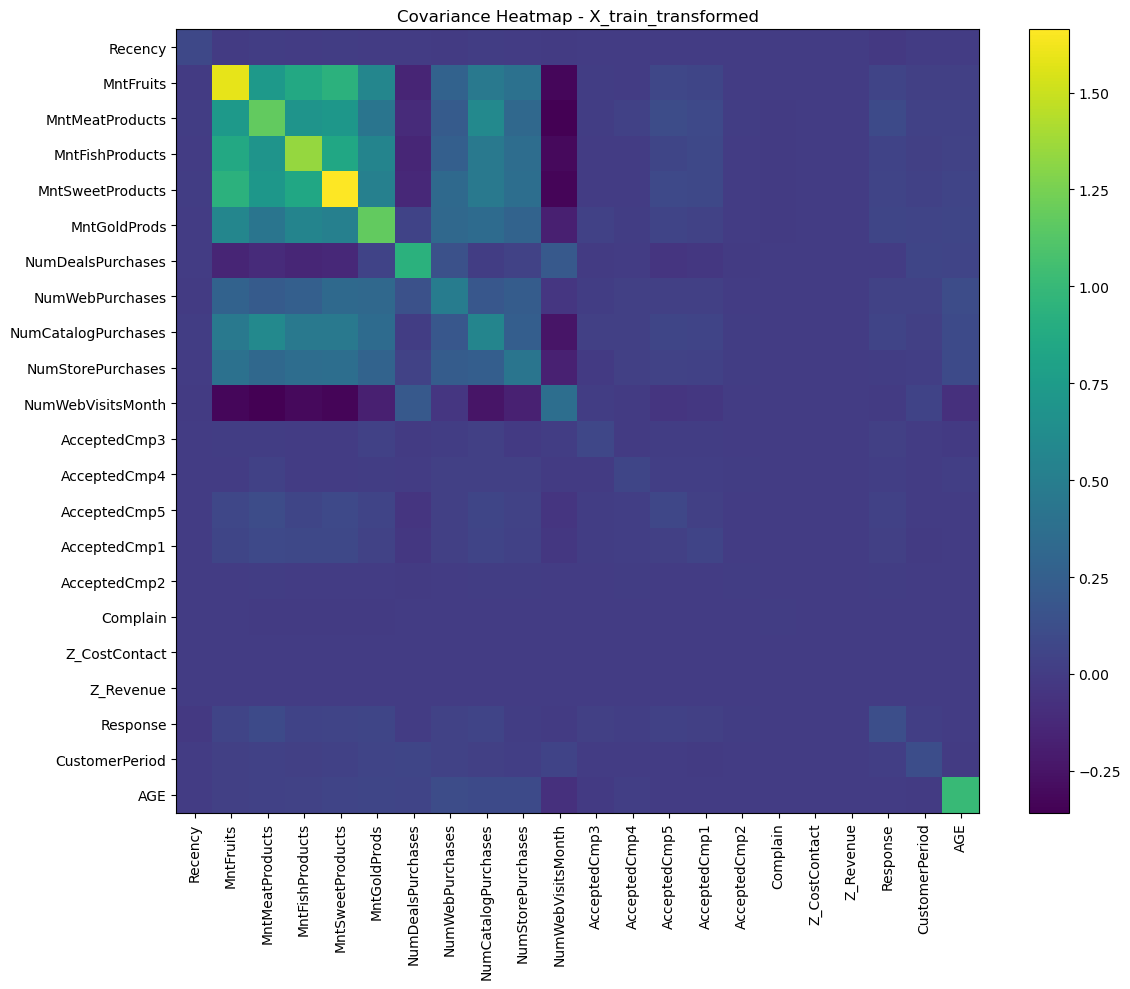

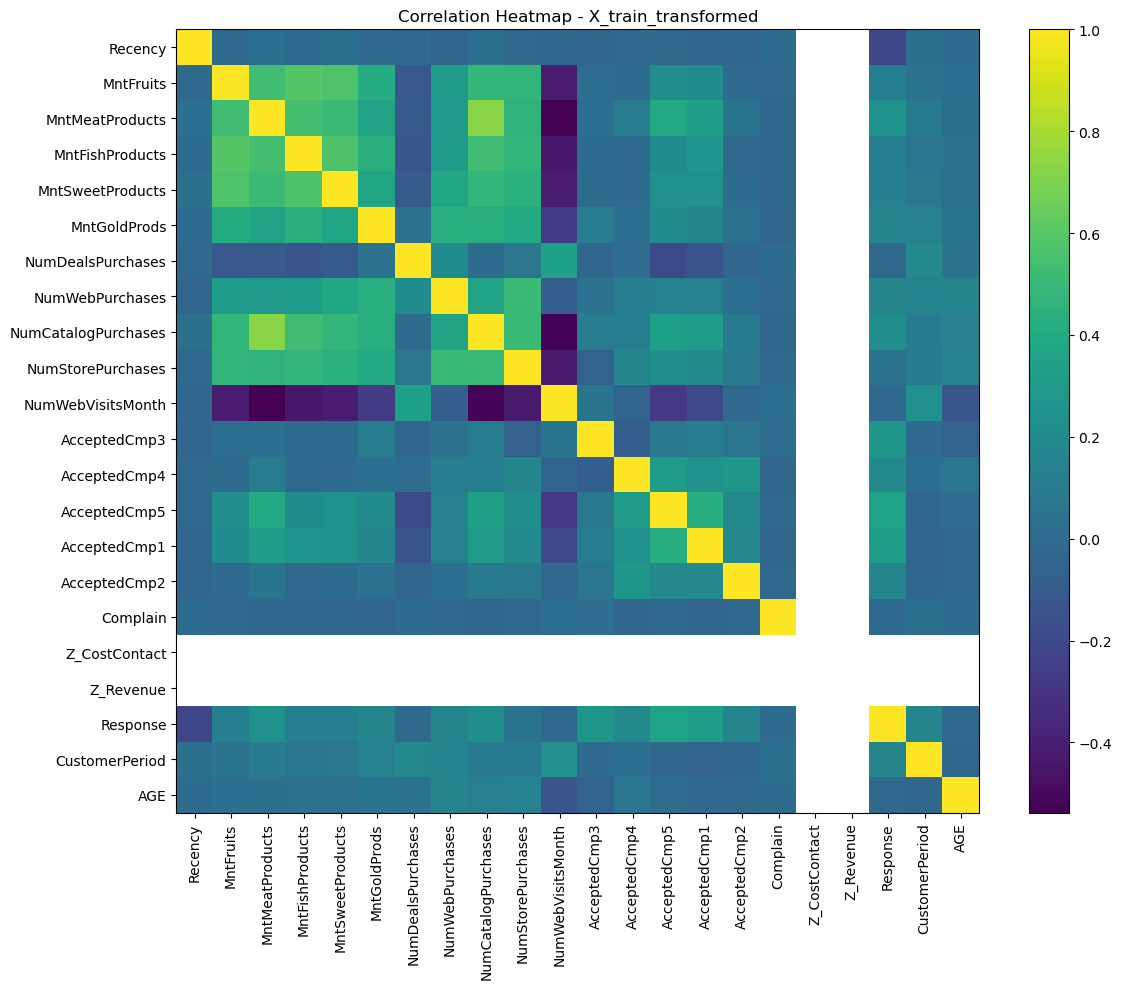

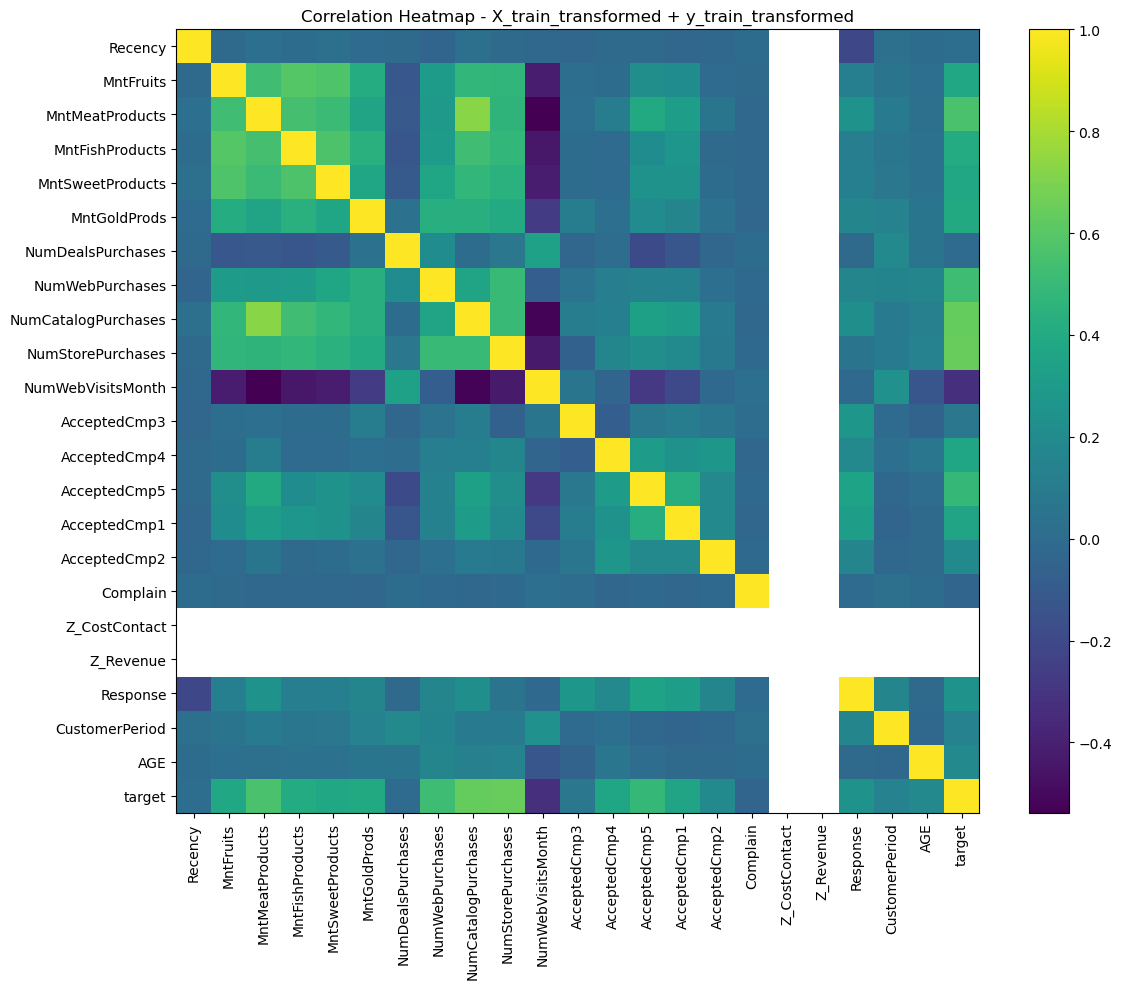


Explained variance table:
      PC  ExplainedVariance  ExplainedVarianceRatio  CumulativeVarianceRatio
0    PC1           4.920549                0.433368                 0.433368
1    PC2           1.195818                0.105319                 0.538687
2    PC3           0.976462                0.086000                 0.624687
3    PC4           0.800916                0.070539                 0.695226
4    PC5           0.749649                0.066024                 0.761250
5    PC6           0.665801                0.058639                 0.819889
6    PC7           0.561581                0.049460                 0.869349
7    PC8           0.347491                0.030605                 0.899954
8    PC9           0.273771                0.024112                 0.924066
9   PC10           0.186603                0.016435                 0.940500
10  PC11           0.157774                0.013896                 0.954396
11  PC12           0.133639                0.0117

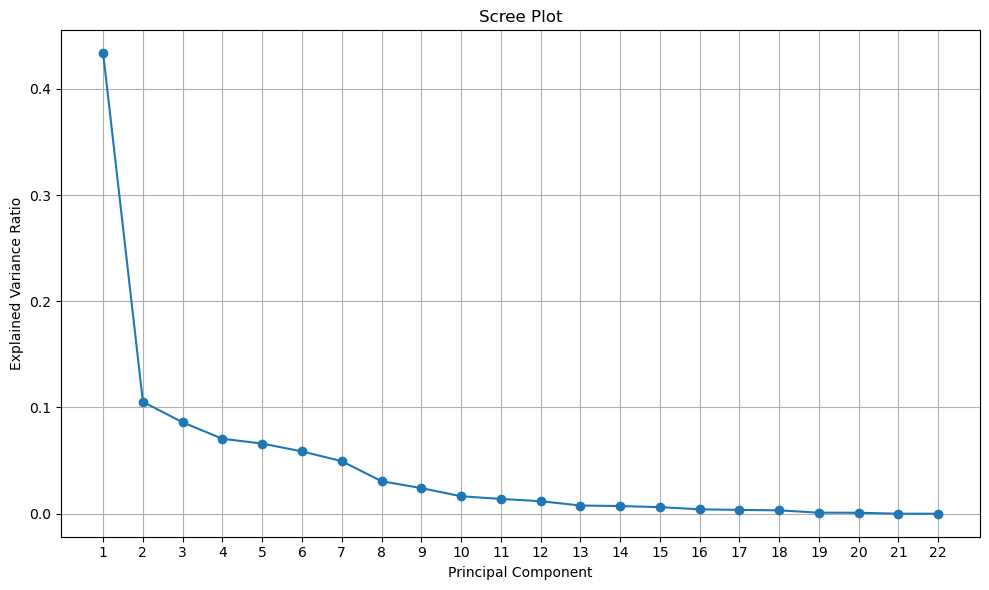

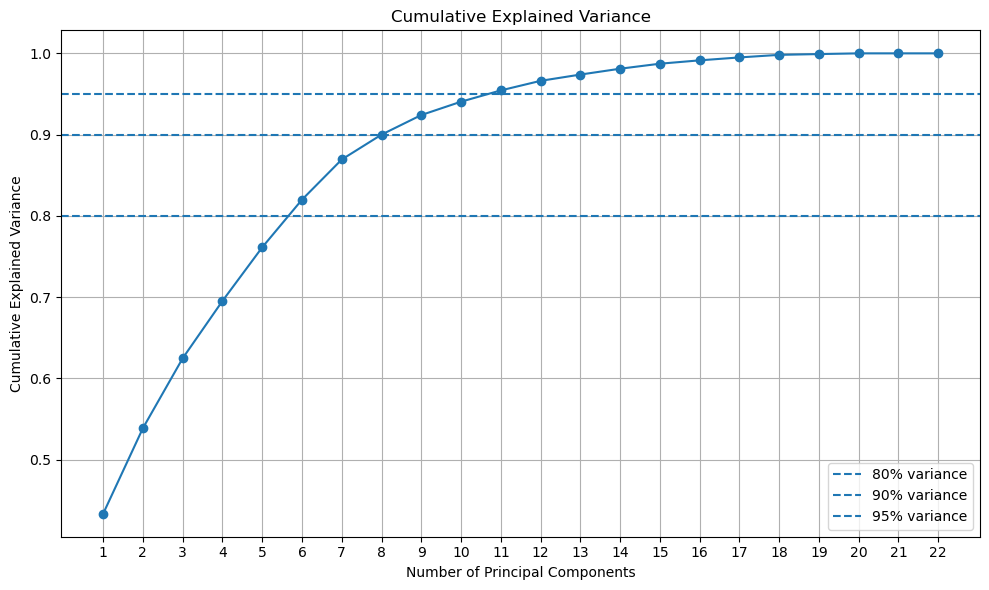


Number of PCs for 80% variance: 6
Number of PCs for 90% variance: 9
Number of PCs for 95% variance: 11

PCA loadings:
                          PC1       PC2       PC3       PC4       PC5  \
Recency              0.001706 -0.004658  0.005179  0.005627  0.008324   
MntFruits            0.464703 -0.137549 -0.080849  0.108215 -0.247513   
MntMeatProducts      0.376869 -0.071179  0.092607 -0.280392  0.650469   
MntFishProducts      0.422055 -0.073367 -0.016075 -0.100692 -0.051906   
MntSweetProducts     0.468582 -0.102566 -0.001925  0.699724 -0.090006   
MntGoldProds         0.300572  0.380311 -0.284730 -0.504321 -0.482999   
NumDealsPurchases   -0.054346  0.673586 -0.372035  0.306875  0.349499   
NumWebPurchases      0.150699  0.303018 -0.067119  0.052532 -0.030423   
NumCatalogPurchases  0.246336  0.090127  0.072866 -0.173016  0.329183   
NumStorePurchases    0.188394  0.141714  0.015394 -0.014859  0.055615   
NumWebVisitsMonth   -0.161772  0.131320 -0.192032  0.137534 -0.075518   
Accep

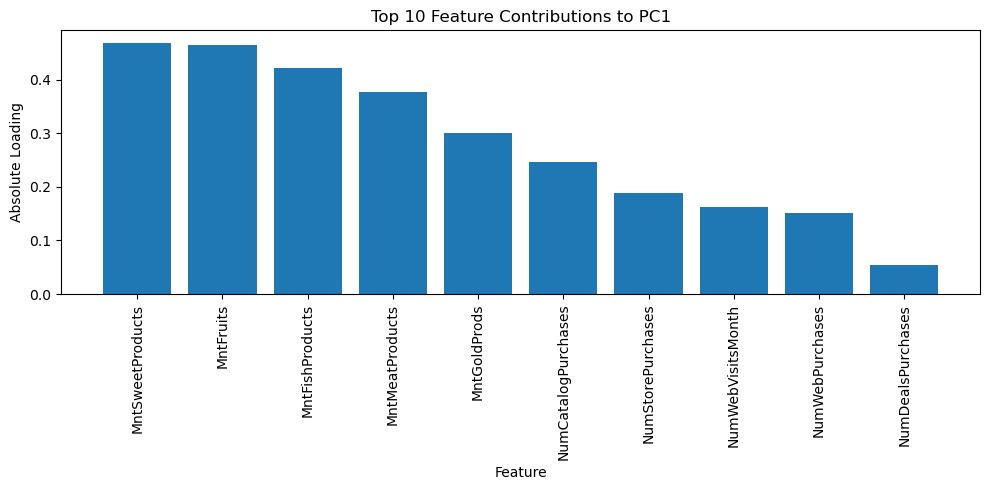

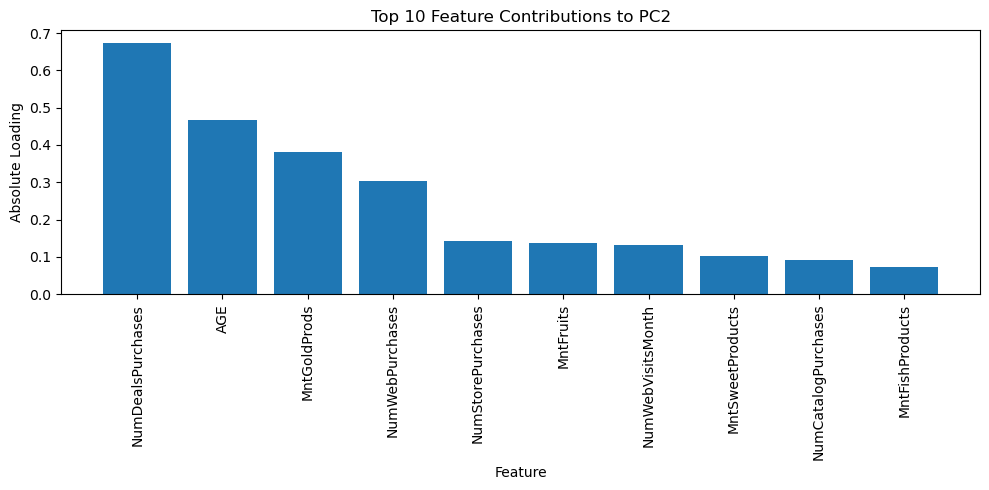

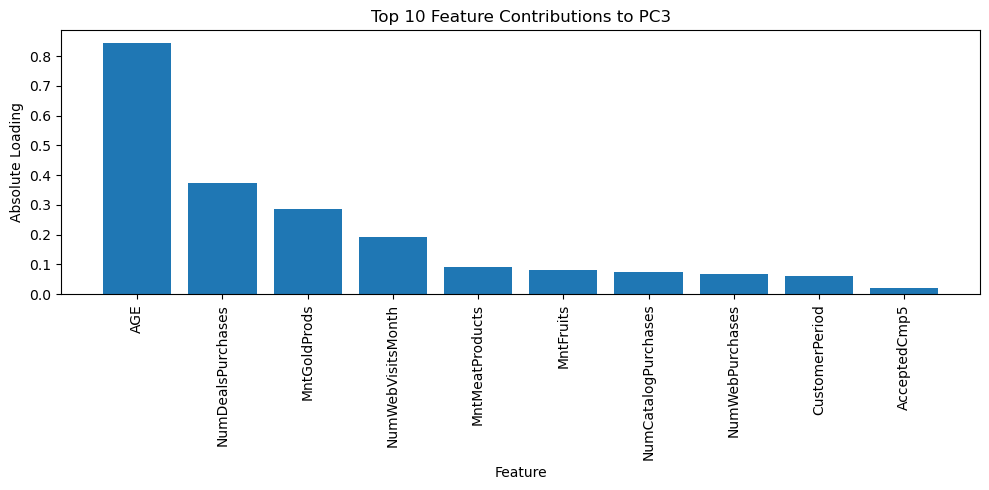

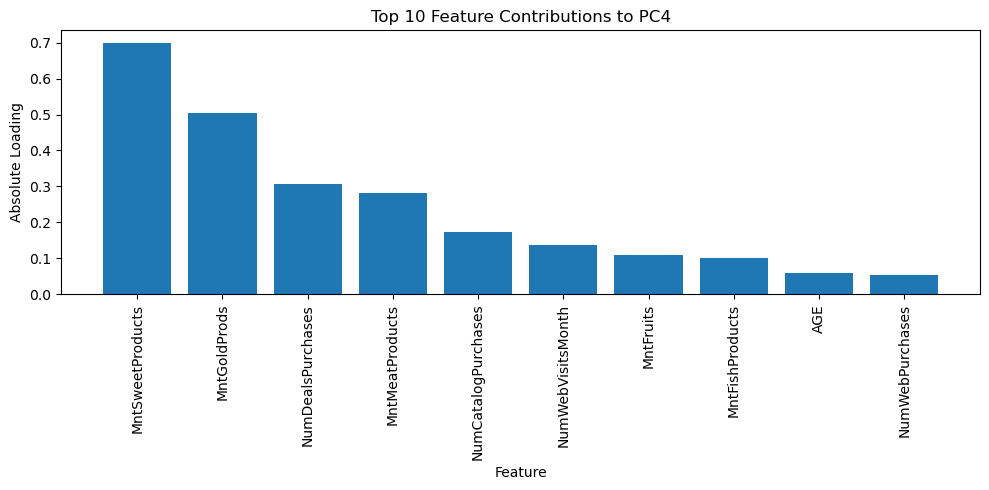

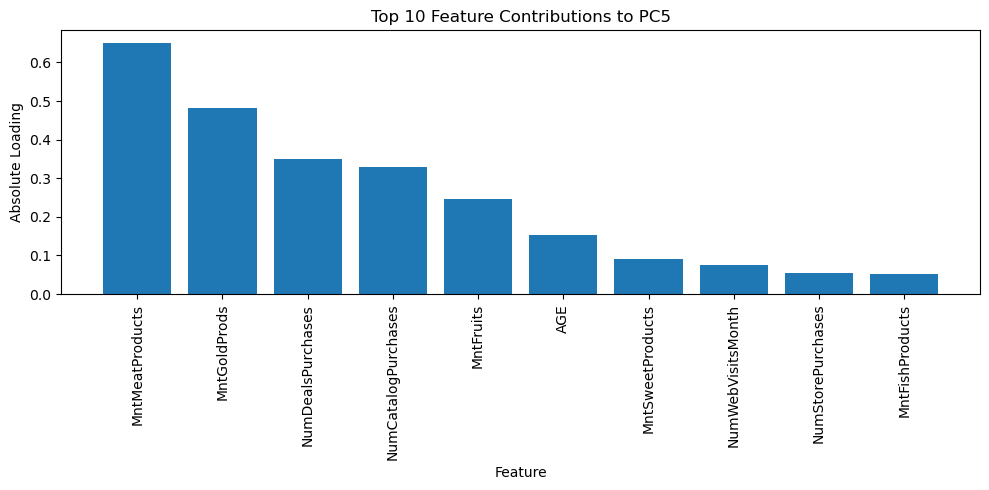

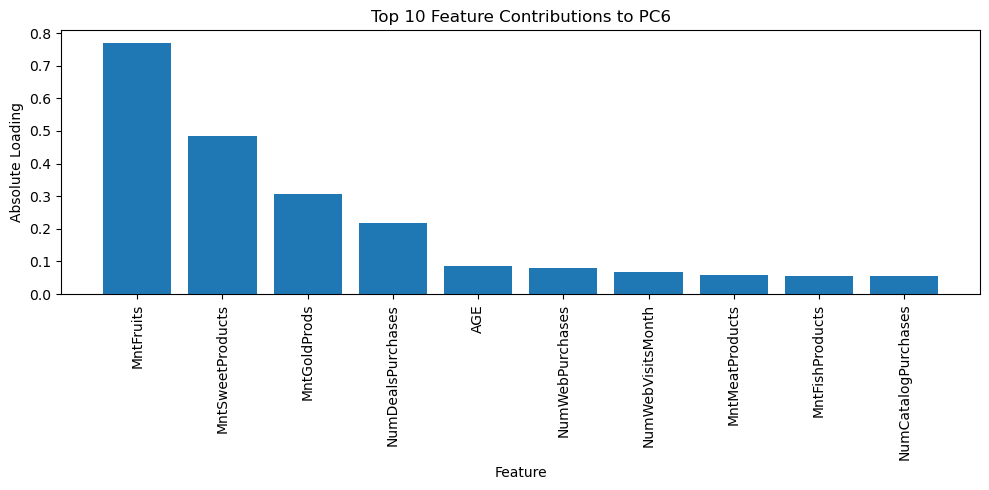

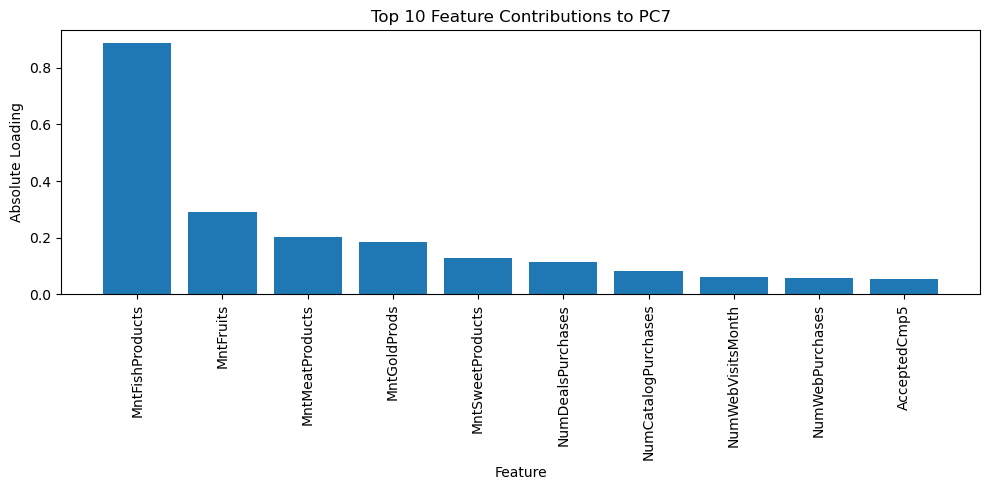

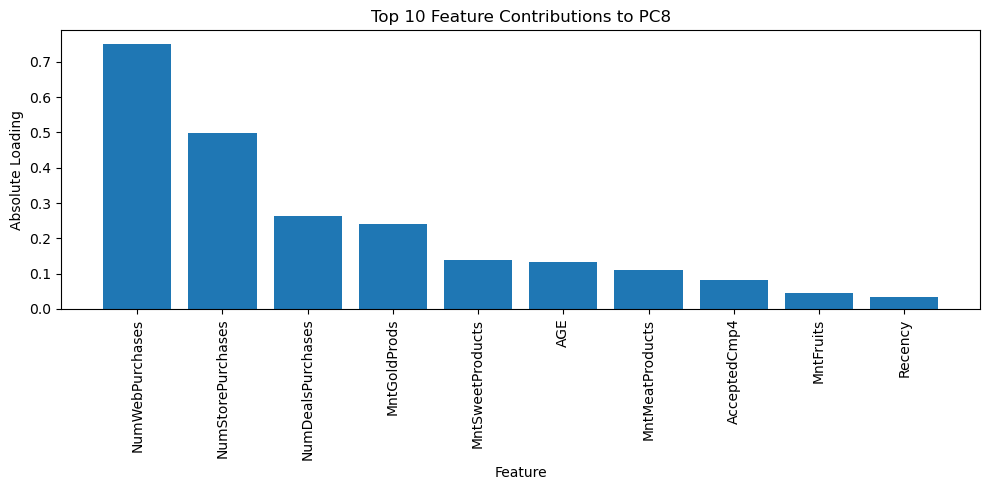

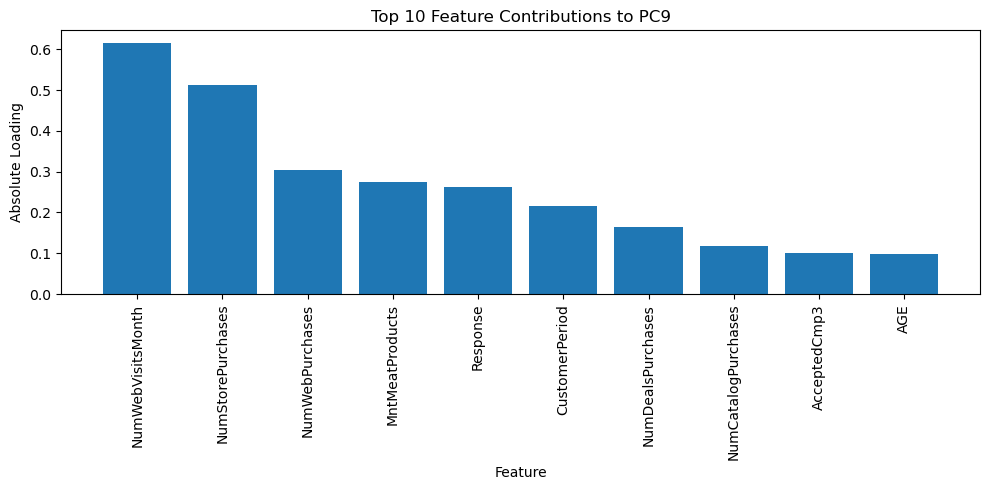

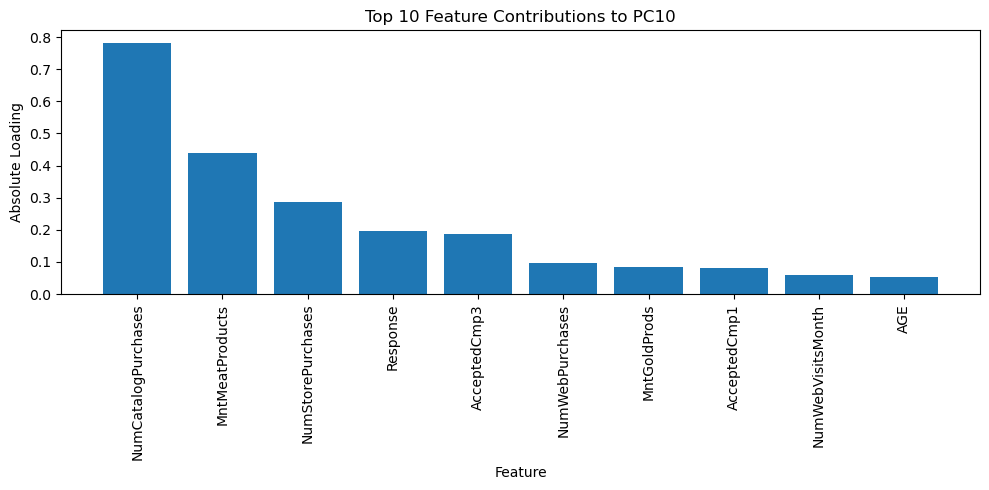

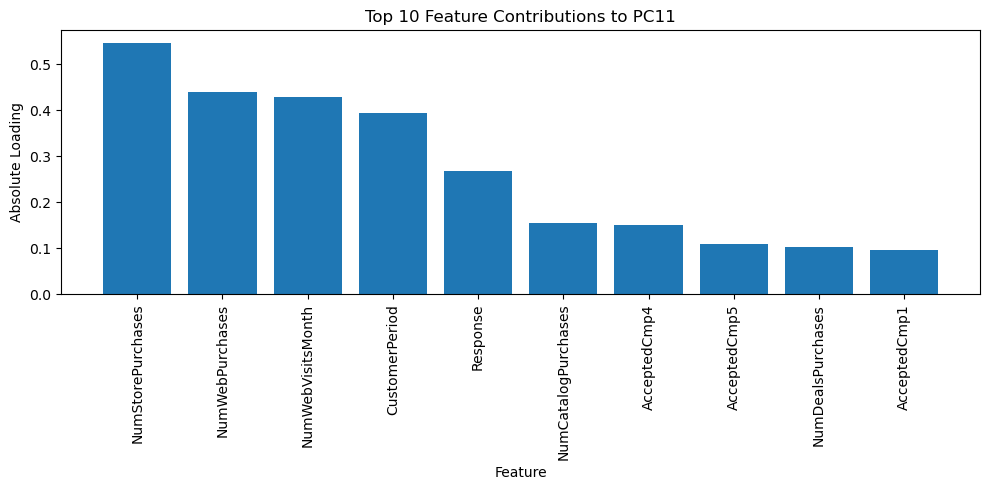


Correlation of PCs with y_train_transformed:
PC1     0.592943
PC8     0.314373
PC2     0.225295
PC11    0.223636
PC5     0.201596
PC4    -0.156327
PC14    0.133172
PC13   -0.114808
PC3     0.099659
PC16    0.098757
PC7    -0.091510
PC10    0.088318
PC18    0.076359
PC15   -0.076065
PC6    -0.068243
PC12    0.060430
PC21    0.033317
PC20    0.029814
PC19   -0.020382
PC22   -0.017429
PC17    0.008811
PC9    -0.007716
Name: target, dtype: float64


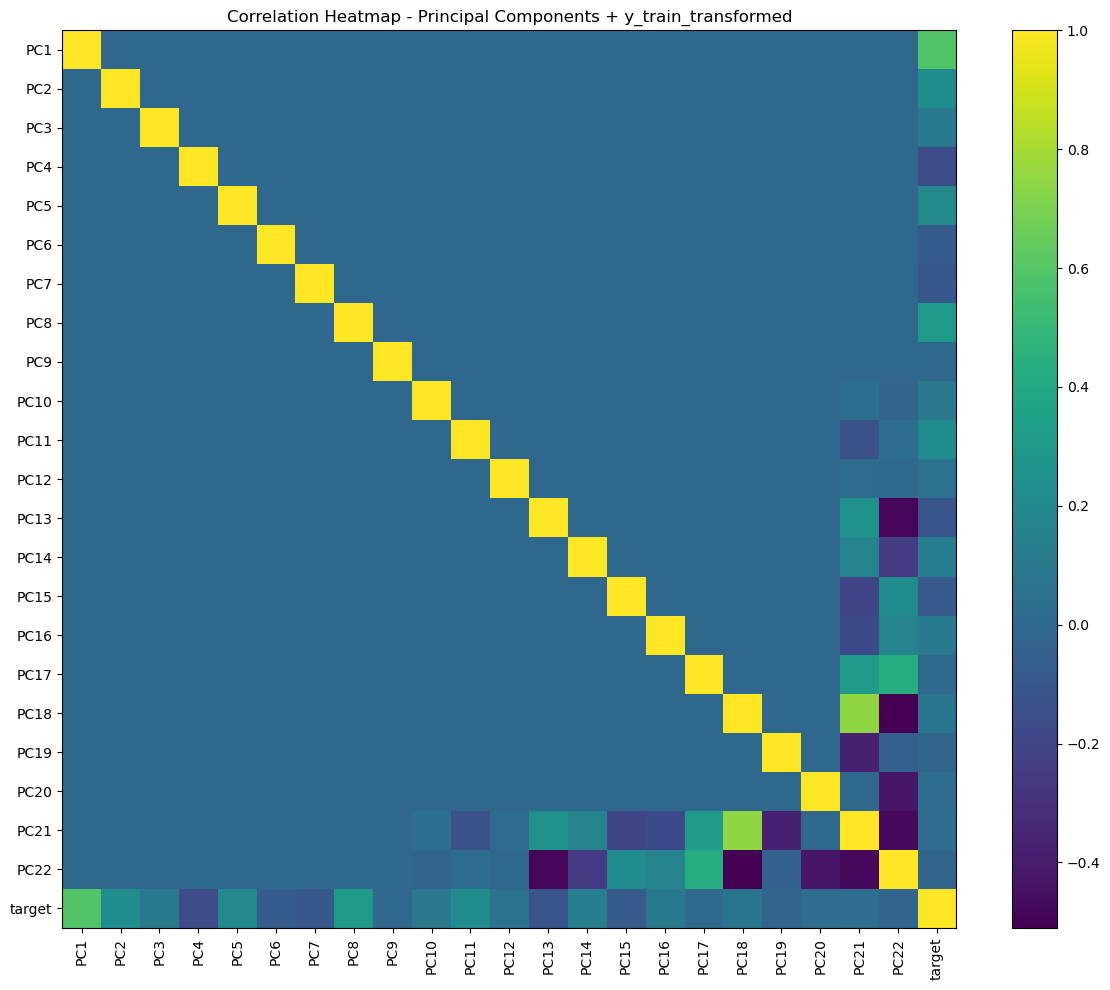

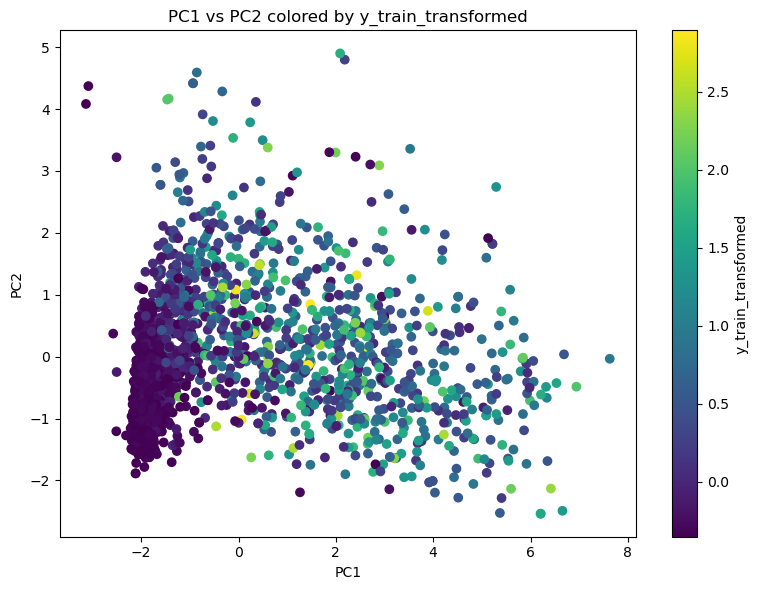


Reduced X_train PCA shape (9 PCs): (1792, 9)
Reduced X_test PCA shape (9 PCs): (448, 9)

First rows of reduced X_train PCA:
           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
792  -1.653253  0.084451  1.636747  0.005642 -0.693630  0.209224  0.102969   
1271  1.281388  0.284812  0.584058  0.281974  0.452167 -0.010322  2.315542   
1538 -1.455679  0.361316 -0.123929 -0.015261  0.666018  0.093158 -0.080793   
668  -2.127855 -0.696578  0.432971  0.047467 -0.286513  0.030590  0.033953   
1975  1.112300  2.924876 -1.430941 -3.292729 -3.771517 -2.687415 -1.733890   

           PC8       PC9  
792  -0.311276  0.528264  
1271  0.768547 -0.863466  
1538  0.538581 -0.249723  
668  -0.189633  0.324444  
1975  2.517376  1.305191  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_test.columns, index=X_test.index)


X_train_num = X_train_transformed.select_dtypes(include='number').copy()
X_test_num = X_test_transformed.select_dtypes(include='number').copy()

print("X_train shape:", X_train_num.shape)
print("X_test shape:", X_test_num.shape)
print("y_train shape:", y_train_transformed.shape)
print("y_test shape:", y_test_transformed.shape)


cov_matrix = X_train_num.cov()
corr_matrix = X_train_num.corr()

print("\nCovariance matrix:")
print(cov_matrix)

print("\nCorrelation matrix:")
print(corr_matrix)


train_with_y = X_train_num.copy()
train_with_y["target"] = y_train_transformed

feature_target_corr = train_with_y.corr()["target"].drop("target").sort_values(key=np.abs, ascending=False)

print("\nCorrelation of original features with y_train_transformed:")
print(feature_target_corr)

def plot_heatmap(matrix, title, figsize=(12, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(matrix, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
    plt.yticks(range(len(matrix.index)), matrix.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(cov_matrix, "Covariance Heatmap - X_train_transformed")
plot_heatmap(corr_matrix, "Correlation Heatmap - X_train_transformed")

# Heatmap including y
corr_with_y_matrix = train_with_y.corr()
plot_heatmap(corr_with_y_matrix, "Correlation Heatmap - X_train_transformed + y_train_transformed")

# =========================================================
# 4. FIT PCA ON X_train ONLY
# =========================================================
pca = PCA()
X_train_pca = pca.fit_transform(X_train_num)
X_test_pca = pca.transform(X_test_num)

pc_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pc_names, index=X_train_num.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pc_names, index=X_test_num.index)

# =========================================================
# 5. EXPLAINED VARIANCE
# =========================================================
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance = pca.explained_variance_
cumulative_variance = np.cumsum(explained_variance_ratio)

explained_df = pd.DataFrame({
    "PC": pc_names,
    "ExplainedVariance": explained_variance,
    "ExplainedVarianceRatio": explained_variance_ratio,
    "CumulativeVarianceRatio": cumulative_variance
})

print("\nExplained variance table:")
print(explained_df)

# =========================================================
# 6. PLOTS: SCREE + CUMULATIVE
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.80, linestyle='--', label='80% variance')
plt.axhline(y=0.90, linestyle='--', label='90% variance')
plt.axhline(y=0.95, linestyle='--', label='95% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# How many PCs to keep
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nNumber of PCs for 80% variance: {n_80}")
print(f"Number of PCs for 90% variance: {n_90}")
print(f"Number of PCs for 95% variance: {n_95}")


loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train_num.columns,
    columns=pc_names
)

print("\nPCA loadings:")
print(loadings)

# Absolute loadings = contribution strength
abs_loadings = loadings.abs()

print("\nAbsolute PCA loadings:")
print(abs_loadings)


top_n = 10

for pc in pc_names:
    print(f"\nTop {top_n} contributing features for {pc}:")
    print(abs_loadings[pc].sort_values(ascending=False).head(top_n))

# =========================================================
# 9. BAR PLOTS OF TOP CONTRIBUTORS PER PC
# =========================================================
for pc in pc_names[:min(11, len(pc_names))]:  # first 6 PCs for readability
    top_features = abs_loadings[pc].sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(top_features.index, top_features.values)
    plt.title(f"Top {top_n} Feature Contributions to {pc}")
    plt.xlabel("Feature")
    plt.ylabel("Absolute Loading")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


pca_with_y = X_train_pca_df.copy()
pca_with_y["target"] = y_train_transformed

pc_target_corr = pca_with_y.corr()["target"].drop("target").sort_values(key=np.abs, ascending=False)

print("\nCorrelation of PCs with y_train_transformed:")
print(pc_target_corr)

plot_heatmap(pca_with_y.corr(), "Correlation Heatmap - Principal Components + y_train_transformed")


if X_train_pca_df.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_train_pca_df["PC1"],
        X_train_pca_df["PC2"],
        c=y_train_transformed
    )
    plt.colorbar(scatter, label="y_train_transformed")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PC1 vs PC2 colored by y_train_transformed")
    plt.tight_layout()
    plt.show()


n_components_to_keep = n_90  # change to n_80 / n_95 if you want

pca_reduced = PCA(n_components=n_components_to_keep)
X_train_pca_reduced = pca_reduced.fit_transform(X_train_num)
X_test_pca_reduced = pca_reduced.transform(X_test_num)

reduced_pc_names = [f"PC{i+1}" for i in range(n_components_to_keep)]

X_train_pca_reduced_df = pd.DataFrame(
    X_train_pca_reduced,
    columns=reduced_pc_names,
    index=X_train_num.index
)

X_test_pca_reduced_df = pd.DataFrame(
    X_test_pca_reduced,
    columns=reduced_pc_names,
    index=X_test_num.index
)

print(f"\nReduced X_train PCA shape ({n_components_to_keep} PCs):", X_train_pca_reduced_df.shape)
print(f"Reduced X_test PCA shape ({n_components_to_keep} PCs):", X_test_pca_reduced_df.shape)

print("\nFirst rows of reduced X_train PCA:")
print(X_train_pca_reduced_df.head())

Regression

In [118]:
one_hot_cols = [
    c for c in X_train.select_dtypes(exclude="number").columns
]

numeric_cols = [
    c for c in X_train.select_dtypes(include='number').columns
    if c not in one_hot_cols
]

print(one_hot_cols)
print(numeric_cols)

['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO', 'Kidhome_0', 'Kidhome_1', 'Kidhome_2', 'Teenhome_0', 'Teenhome_1', 'Teenhome_2']
['Recency', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'CustomerPeriod', 'AGE']


In [126]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# choose number of components (90%)
n_components = np.argmax(cum_var >= 0.95) + 1
print("Using components:", n_components)

# reduce
pca_final = PCA(n_components=n_components)

X_train_pca = pca_final.fit_transform(X_train_transformed[numeric_cols])
X_test_pca = pca_final.transform(X_test_transformed[numeric_cols])

pc_names = [f"PC{i+1}" for i in range(n_components)]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pc_names, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pc_names, index=X_test.index)

Using components: 11


In [127]:
X_train_final = pd.concat([X_train_pca_df, X_train[one_hot_cols]], axis=1)
X_test_final = pd.concat([X_test_pca_df, X_test[one_hot_cols]], axis=1)

In [130]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.001)
model.fit(X_train_final, y_train_transformed)

Lasso(alpha=0.001)

In [131]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_final)
mse = mean_squared_error(y_test_transformed, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_transformed, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.46106582402147867
R2: 0.6162329085718905


In [132]:
coef_df = pd.DataFrame({
    "feature": X_train_final.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=np.abs, ascending=False)

print(coef_df.head(20))

                    feature  coefficient
10                     PC11     0.396248
7                       PC8     0.354837
0                       PC1     0.189946
4                       PC5     0.156893
15            Education_PhD     0.156233
1                       PC2     0.132633
9                      PC10     0.126163
14         Education_Master     0.122764
3                       PC4    -0.117219
11       Education_2n Cycle    -0.086281
6                       PC7    -0.077564
24                Kidhome_0     0.067056
5                       PC6    -0.059243
2                       PC3     0.043129
28               Teenhome_1     0.026802
21  Marital_Status_Together     0.024677
20    Marital_Status_Single    -0.017446
22     Marital_Status_Widow    -0.007980
19   Marital_Status_Married     0.005572
25                Kidhome_1    -0.004190


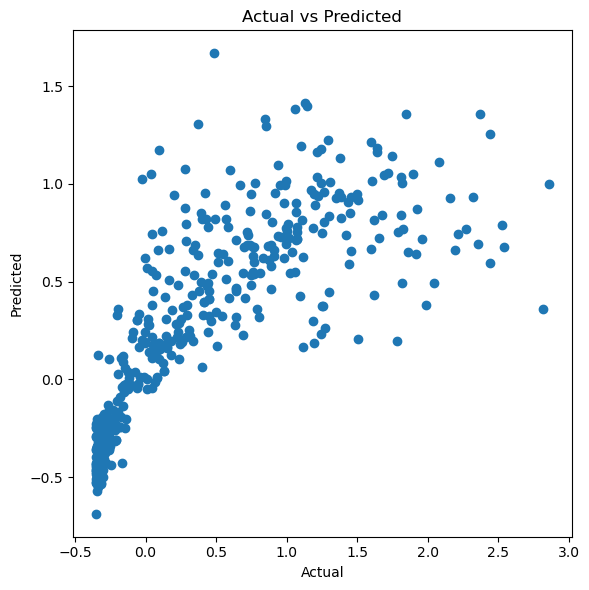

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_transformed, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

Saved as qr_with_name.png
